# 🧪 [Assignment 8] Vanilla MLP vs Upsampled MLP

In this assignment, you’ll build and compare two neural-network classifiers on the **Glass Identification** dataset from Kaggle:

🔗 https://www.kaggle.com/datasets/uciml/glass

You will train a **Vanilla MLP (baseline)** and an **Upsampled MLP (class-imbalance aware)**, then evaluate which approach generalizes better. Along the way, you’ll practice **normalization, train/test splits, class distribution analysis, confusion matrices, and learning curves**. 🚀


## Step 1: Setup 📂📦

Download the csv file named **glass.csv**, upload it to your colab and load it to a DataFrame named `data`

Dataset reference:
https://www.kaggle.com/datasets/uciml/glass


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv('glass.csv')
print("The number of records in this dataset is ", len(data))

The number of records in this dataset is  214


In [2]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Step 2: Defining the Problem 🎯

We are solving a **multi-class classification** task:

- The **`Type`** column is the **label** (target class).
- All other columns are **features** (inputs).

Our goal is to train a model that uses the features to predict the **Type** of glass.

## Step 3: Data Encoding ✅

No encoding is required — all columns are already **numeric** (as you can verify with `data.info()`).

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


## Step 4: Label Analysis 📊

Use the commands below to inspect the values in the `Type` column and plot its histogram.

You should notice:
- There are **7 possible classes** (1 through 7).
- The dataset is **imbalanced** — some classes have far fewer records.
- **Class 4 is absent** (no rows with `Type == 4`). Confirm with:

```python
data[data["Type"] == 4]
```

**Teaching note:** Class imbalance can bias a model toward majority classes. We’ll address this later via **upsampling**.


In [4]:
data['Type']

,Type
0,1
1,1
2,1
3,1
4,1
...,...
209,7
210,7
211,7
212,7


<Axes: >

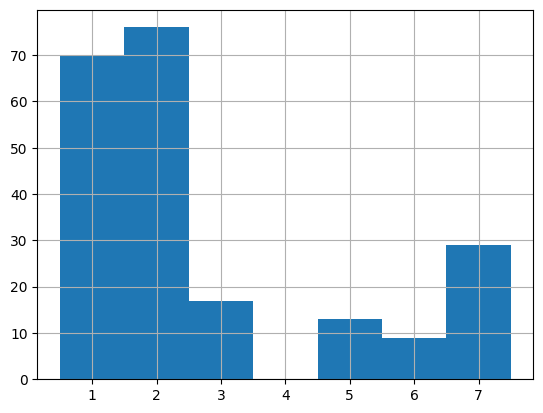

In [5]:
data['Type'].hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

In [6]:
data[data['Type']==4]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


## Step 5: Normalize Features 📏

Use `StandardScaler` to normalize all **feature columns** (exclude the label).

- Save the normalized features in a DataFrame named **`data_n_df`**.
- **Preserve original column names**.
- Keep the label separately as `labels` (e.g., `labels = data["Type"]`).

**Why normalize?** MLPs and distance-based methods train more stably and faster when features are on similar scales.


In [7]:
from sklearn.preprocessing import StandardScaler
### BEGIN SOLUTION

scaler = StandardScaler()

features = data.drop('Type', axis=1)
labels = data['Type']

scaled_features = scaler.fit_transform(features)

data_n_df = pd.DataFrame(scaled_features, columns=features.columns)


### END SOLUTION

In [8]:
#if you did the normalization correct, the follwoing command should print True
round(data_n_df['RI'].mean())+round(data_n_df['K'].mean())==0

True

## Step 6: Explore Feature Correlations 🔗

Just for exploration, visualize the **pairwise correlations** among features (e.g., via a heatmap).  
This helps you see which features move together.

<font color='red'>Important:</font> This is **exploratory only** — do **not** drop features based on correlation in this assignment.


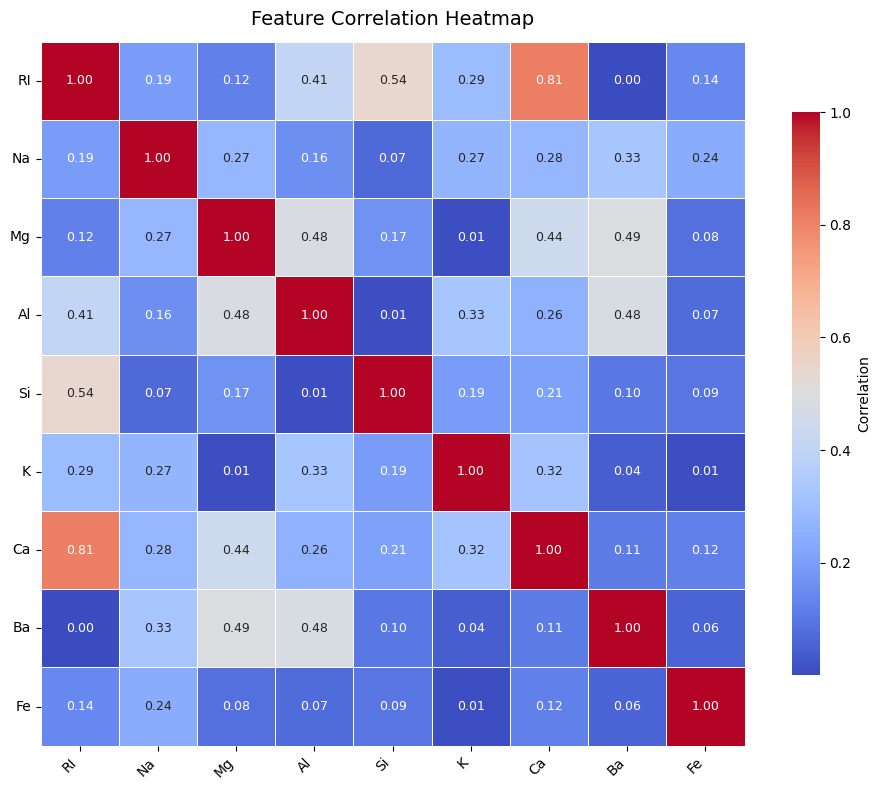

In [9]:
import seaborn as sns

# Compute absolute correlation matrix
corr = abs(data_n_df.corr())

# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,            # ✅ show correlation values
    fmt=".2f",             # 2 decimal places
    cmap="coolwarm",       # visually balanced color map
    square=True,
    linewidths=0.5,        # fine grid lines
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"size": 9}  # font size for annotations
)

# Improve title and layout
plt.title("Feature Correlation Heatmap", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
data_n_df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


## Step 7: Split the Data ✂️

Use  `train_test_split` from Scikit-learn and split the Features and Label(Y) to **70%** training subset and **30%** test subset. Use the variable names as shown below.

- <font color=red>Use `random_state=10` for reproducibility (everyone gets the same split).


In [13]:
from sklearn.model_selection import train_test_split
### BEGIN SOLUTION
X_train, X_test, Y_train, Y_test = train_test_split(
    data_n_df,
    labels,
    test_size=0.3,
    random_state=10
)

### END SOLUTION

<Axes: >

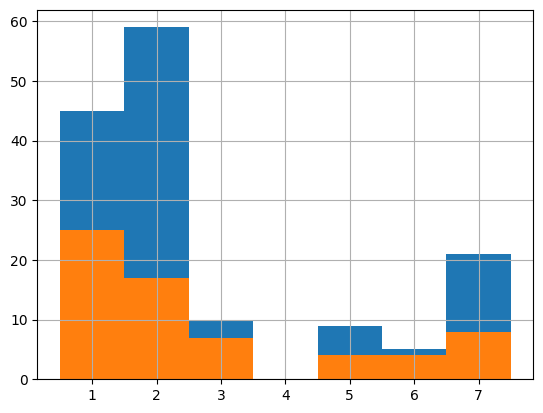

In [14]:
#Review the following histograms and see how data is split.
Y_train.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])
Y_test.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

## Step 8: MLP + Grid Search 🤖🔍 (5 points)

You’ll train an **MLPClassifier** and run a **grid search** over a few key hyperparameters.
Then you’ll select the **best model** based on cross-validation performance and evaluate on the test set.

**Teaching note:** An MLP (Multi-Layer Perceptron) is a feed-forward neural network. We’ll try different hidden-layer sizes and training settings to see what works best.


### 8.1 Define Your Hyperparameter Grid

Check `MLPClassifier` documentation in the following link:

👉 https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

And form your grid including **only** the following keys:

- `'hidden_layer_sizes'`
-  `'activation'`
- `'solver'`
- `'learning_rate'`
- `'max_iter'`

Do **not** include other parameters. Start with a small grid, then expand if needed.


In [15]:
### BEGIN SOLUTION


param_cases={

    'hidden_layer_sizes': [(10,), (20,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000]


}



### END SOLUTION

### 8.2 Train Models via Grid Search

Complete the code to run `GridSearchCV` over your MLP parameter grid
Fit on the **training set** and select the **best estimator**.

<font color='red'>Note:</font> If your accuracy is initially low, **iterate** on the grid (try a couple more hidden-layer sizes or solvers). Aim for **~80%** test accuracy.


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
### BEGIN SOLUTION


mlp = MLPClassifier()

grid = GridSearchCV(
    mlp,
    param_cases,
    cv=5
)

grid.fit(X_train, Y_train)

MLP_Best = grid

### END SOLUTION

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

### 8.3 Review Results Table

Run the following command to see the result in **descending** order.

Look at which combinations of hyperparameters performed best.


In [19]:
pd.concat([pd.DataFrame(MLP_Best.cv_results_["params"]),pd.DataFrame(MLP_Best.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1).sort_values(by=['Accuracy'], ascending=False)

,activation,hidden_layer_sizes,learning_rate,max_iter,solver,Accuracy
34,tanh,"(20,)",constant,1000,adam,0.765057
22,relu,"(10, 10)",adaptive,1000,adam,0.758851
20,relu,"(10, 10)",adaptive,500,adam,0.758391
18,relu,"(10, 10)",constant,1000,adam,0.752644
46,tanh,"(10, 10)",adaptive,1000,adam,0.752184
10,relu,"(20,)",constant,1000,adam,0.745287
2,relu,"(10,)",constant,1000,adam,0.744828
8,relu,"(20,)",constant,500,adam,0.738391
12,relu,"(20,)",adaptive,500,adam,0.738391
4,relu,"(10,)",adaptive,500,adam,0.738391


### 8.4 Confusion Matrix 📉

Plot the **confusion matrix** of your best model on the **test set** using:

- `confusion_matrix`
- `ConfusionMatrixDisplay`


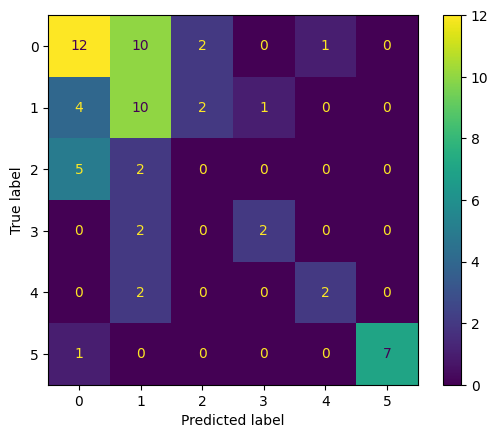

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix(Y_test,MLP_Best.predict(X_test)))
disp.plot()

### 8.5 Classification Report 🧾

Print the **classification report** (precision, recall, f1-score, support) for your best model on the test set.


In [21]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, MLP_Best.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           1       0.55      0.48      0.51        25
           2       0.38      0.59      0.47        17
           3       0.00      0.00      0.00         7
           5       0.67      0.50      0.57         4
           6       0.67      0.50      0.57         4
           7       1.00      0.88      0.93         8

    accuracy                           0.51        65
   macro avg       0.54      0.49      0.51        65
weighted avg       0.52      0.51      0.50        65



**Reflection:**  
If your classification report shows strong performance on majority classes but weak on minority classes, that’s a sign of **class imbalance** affecting the model. Compare with the confusion matrix (Step 8.4) to see which classes are being confused or missed.


## Step 9: MLP with Upsampling 🤖📈 (5 points)

To address **class imbalance**, we’ll **upsample** underrepresented classes, then repeat the MLP training + grid search.  
This helps the model see more samples from minority classes during training.


### 9.1 Build a Combined DataFrame

Create a single DataFrame that contains:
- All **normalized features** (`data_n_df`)
- The **label** column `Type`

Name it something like `data_n_with_label` for clarity.


<Axes: >

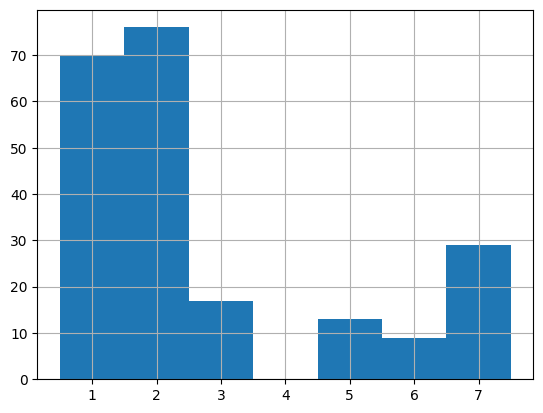

In [22]:
#run this block of code to see the distribution of labels one more time!
data['Type'].hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

**Observation:**  
From your earlier label histogram, classes like **3, 5, 6, 7** have **fewer records**. These are the classes to **upsample** so the training set becomes more balanced.


In [23]:
#run this block to get features and label all in one DataFrame
data_n_df_all=pd.concat([data_n_df, data['Type']],axis=1)

In [24]:
#let's look at the DataFrame
data_n_df_all.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451,1
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451,1
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451,1
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451,1
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451,1


### 9.2 Upsampling Strategy

Use `sklearn.utils.resample` (with `replace=True`) to **upsample** minority classes to match a target size (e.g., the count of a majority class).

Docs: https://scikit-learn.org/stable/modules/generated/sklearn.utils.resample.html


In [25]:
from sklearn.utils import resample
#In the following line, we create a new dataframe by including only type=1 and type=2 because these two classes already have enough records and do not need to upsample (look at the histogram in 9.1)
data_n_df_upsampled=data_n_df_all[(data['Type']==1) | (data['Type']==2)].copy()

Write code to:
1) **Upsample** classes **3, 5, 6, 7** so that each of them have **70 records**.  
2) **Concat** all class DataFrames together into `data_n_df_upsampled`.  

Be sure not to leak test data — only upsample within the **training data**.


In [26]:
### BEGIN SOLUTION


type3_upsampled = resample(
    data[data['Type'] == 3],
    replace=True,
    n_samples=70,
    random_state=10
)

type5_upsampled = resample(
    data[data['Type'] == 5],
    replace=True,
    n_samples=70,
    random_state=10
)

type6_upsampled = resample(
    data[data['Type'] == 6],
    replace=True,
    n_samples=70,
    random_state=10
)

type7_upsampled = resample(
    data[data['Type'] == 7],
    replace=True,
    n_samples=70,
    random_state=10
)

data_n_df_upsampled = pd.concat(
    [
        data_n_df_upsampled,
        type3_upsampled,
        type5_upsampled,
        type6_upsampled,
        type7_upsampled
    ],
    axis=0
)




### END SOLUTION

<Axes: >

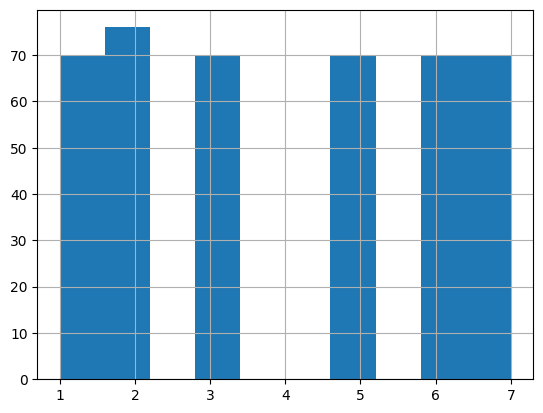

In [27]:
#if you done the upsampling correct, then running the following command should show the data that has 70 records for all classes. Type 2 has just a ccouple of more records.
data_n_df_upsampled['Type'].hist()

### 9.3 Split (Upsampled) ✂️

Use `train_test_split` again on your **upsampled dataset** for training and testing.

- Use `random_state=10` for reproducibility.
- You may still use `stratify` on the labels if appropriate after upsampling.


In [28]:
from sklearn.model_selection import train_test_split
### BEGIN SOLUTION



X_train_U, X_test_U, Y_train_U, Y_test_U = train_test_split(
    data_n_df_upsampled.drop('Type', axis=1),
    data_n_df_upsampled['Type'],
    test_size=0.3,
    random_state=10
)


### END SOLUTION

### 9.4 Grid Search (Upsampled)

Run the **same Grid Search** over the **same hyperparameter grid** you used before.  
Compare results of **Vanilla MLP** vs **Upsampled MLP** on the **test set**.


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
### BEGIN SOLUTION

mlp_u = MLPClassifier()

grid_u = GridSearchCV(
    mlp_u,
    param_cases,
    cv=5
)

grid_u.fit(X_train_U, Y_train_U)




MLP_Best_U = grid_u



### END SOLUTION

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

### 9.5 Review Results Table (Upsampled)

Show the cross-validation results for the upsampled training. Compare to Step 8.3 — which settings improved?

In [30]:
pd.concat([pd.DataFrame(MLP_Best_U.cv_results_["params"]),pd.DataFrame(MLP_Best_U.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1).sort_values(by=['Accuracy'], ascending=False)

,activation,hidden_layer_sizes,learning_rate,max_iter,solver,Accuracy
38,tanh,"(20,)",adaptive,1000,adam,0.906328
10,relu,"(20,)",constant,1000,adam,0.906215
34,tanh,"(20,)",constant,1000,adam,0.902881
22,relu,"(10, 10)",adaptive,1000,adam,0.892712
14,relu,"(20,)",adaptive,1000,adam,0.892542
12,relu,"(20,)",adaptive,500,adam,0.882712
16,relu,"(10, 10)",constant,500,adam,0.879435
2,relu,"(10,)",constant,1000,adam,0.872712
20,relu,"(10, 10)",adaptive,500,adam,0.856045
18,relu,"(10, 10)",constant,1000,adam,0.855763


### 9.6 Confusion Matrix (Upsampled) 📉

Plot the confusion matrix of your **best upsampled model** on the **test set**. Which classes improved?

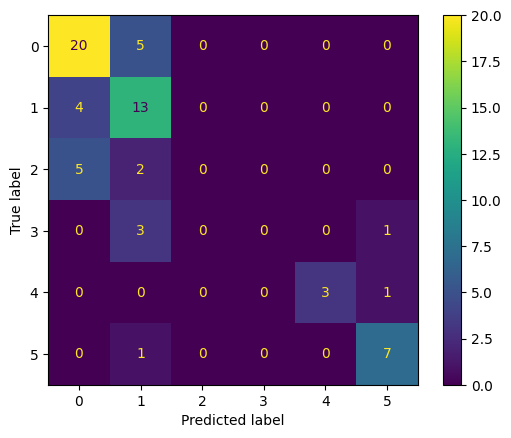

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp2=ConfusionMatrixDisplay(confusion_matrix(Y_test,MLP_Best_U.predict(X_test)))
disp2.plot()

## Step 10: Evaluate on the Original Test Set 🧪

Use the **original (non-upsampled) test set** to evaluate your **Vanilla** and **Upsampled** MLPs.  
Report metrics such as **accuracy, precision, recall, and F1-score**.

Then briefly **reflect**: Which approach generalizes better? Why?

In [32]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, MLP_Best_U.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           1       0.69      0.80      0.74        25
           2       0.54      0.76      0.63        17
           3       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         4
           6       1.00      0.75      0.86         4
           7       0.78      0.88      0.82         8

    accuracy                           0.66        65
   macro avg       0.50      0.53      0.51        65
weighted avg       0.56      0.66      0.60        65



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


🎉 **You made it!** Great work comparing **Vanilla vs Upsampled MLP** on an imbalanced multi-class dataset.

**Think about the next steps:**

In the final confusion matrix, you can see that for **True Value = 0**, there are several **off-diagonal values**, representing false predictions.
This raises an interesting question:

👉 Can we focus on **class 0 versus all** other classes and **fine-tune** the model using the ROC curve to improve its performance?